In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize
# from scipy import optimize

import glob

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

In [3]:
res_list=[]

binsize=5

In [4]:
path="./beta50.000000at0.073868nt32L2/"
files_ = sorted(glob.glob(path+"plaq_ss_t_*.dat"), key=len)
files = np.array(files_)

data_=[]
for file in files:
    data_.append( np.loadtxt( file ) )
data = np.array( data_ )

Nt=data.shape[1]

jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()

res_list.append( [path, jk.mean(), jk.err()] )

In [5]:
path="./beta50.000000at0.276787nt32L1/"
files_ = sorted(glob.glob(path+"plaq_ss_t_*.dat"), key=len)
files = np.array(files_)

data_=[]
for file in files:
    data_.append( np.loadtxt( file ) )
data = np.array( data_ )

Nt=data.shape[1]

jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()

res_list.append( [path, jk.mean(), jk.err()] )

In [6]:
path="./beta50.000000at0.138394nt32L1/"
files_ = sorted(glob.glob(path+"plaq_ss_t_*.dat"), key=len)
files = np.array(files_)

data_=[]
for file in files:
    data_.append( np.loadtxt( file ) )
data = np.array( data_ )

Nt=data.shape[1]

jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()

res_list.append( [path, jk.mean(), jk.err()] )

In [7]:
path="./beta50.000000at0.069197nt32L1/"
files_ = sorted(glob.glob(path+"plaq_ss_t_*.dat"), key=len)
files = np.array(files_)

data_=[]
for file in files:
    data_.append( np.loadtxt( file ) )
data = np.array( data_ )

Nt=data.shape[1]

jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()

res_list.append( [path, jk.mean(), jk.err()] )

In [8]:
path="./beta50.000000at0.034598nt32L1/"
files_ = sorted(glob.glob(path+"plaq_ss_t_*.dat"), key=len)
files = np.array(files_)

data_=[]
for file in files:
    data_.append( np.loadtxt( file ) )
data = np.array( data_ )

Nt=data.shape[1]

jk = Jackknife( data.shape[0], binsize )
jk.set( simple_mean, data )
jk.do_it()

res_list.append( [path, jk.mean(), jk.err()] )

In [9]:
res_list

[['./beta50.000000at0.073868nt32L2/',
  array([ 6.06940535e-01,  2.41196120e-01,  1.49406615e-01,  2.25117176e-02,
         -2.93649719e-03,  3.71543518e-02, -1.68823397e-02,  4.15603894e-02,
          8.31974261e-02,  2.73907731e-02,  7.47774342e-02, -1.16743903e-01,
         -2.65875778e-02, -5.31230372e-02,  2.43279983e-02,  5.77988301e-02,
         -5.54062342e-04,  5.77988301e-02,  2.43279983e-02, -5.31230372e-02,
         -2.65875778e-02, -1.16743903e-01,  7.47774342e-02,  2.73907731e-02,
          8.31974261e-02,  4.15603894e-02, -1.68823397e-02,  3.71543518e-02,
         -2.93649719e-03,  2.25117176e-02,  1.49406615e-01,  2.41196120e-01]),
  array([0.00172326, 0.00096235, 0.00090323, 0.00090986, 0.00070665,
         0.00090509, 0.00068992, 0.0007157 , 0.00086025, 0.00085237,
         0.00078344, 0.00098162, 0.00078722, 0.00074511, 0.00137656,
         0.00106968, 0.00099854, 0.00106968, 0.00137656, 0.00074511,
         0.00078722, 0.00098162, 0.00078344, 0.00085237, 0.00086025,

(0.0001, 1.0)

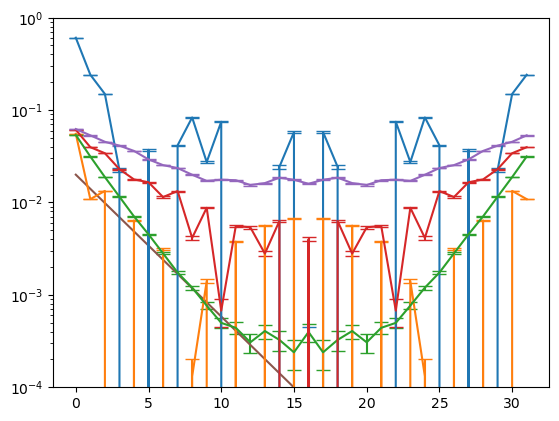

In [11]:
plt.yscale("log")

for res in res_list:
    Nt = res[1].shape[0]

    xx=np.arange(Nt)
    yy=res[1]
    dy=res[2]

    plt.errorbar( xx, yy, dy, capsize=5 )

# xx=np.arange(Nt)
# yy= 0.07*np.exp( -np.sqrt(2.0) * xx / 8.0 )
# plt.plot( xx, yy )

xx=np.arange(Nt)
yy= 0.02*np.exp( -np.sqrt(2.0) * xx / 4.0 )
plt.plot( xx, yy )

# xx=np.arange(Nt)
# yy= 0.005*np.exp( -np.sqrt(2.0) * xx / 2.0 )
# plt.plot( xx, yy )

plt.ylim( 1.0e-4, 1.0e0 )